## Comparing spaCy and Stanza

Since we don't have ground truth labels, we will compare the two models against each other:

*   Agreement rate — how often do both models assign the same entity to the same token?
*   Entity overlap — how many entities are found by both vs only one model?
*   Label confusion — when they disagree, what labels do they each assign?

In [2]:
import pandas as pd

df_spacy_sm = pd.read_csv("df_spacy_sm.csv")
df_spacy_md = pd.read_csv("df_spacy_md.csv")
df_spacy_lg = pd.read_csv("df_spacy_lg.csv")
df_stanza = pd.read_csv("df_stanza.csv")

print(df_spacy_sm.head())
print(df_spacy_md.head())
print(df_spacy_lg.head())
print(df_stanza.head())

print(df_spacy_sm.columns.tolist())
print(df_spacy_md.columns.tolist())
print(df_spacy_lg.columns.tolist())
print(df_stanza.columns.tolist())

                                               title             entity label
0  Innovative Architektur und Stadtentwicklung in...  Frankfurt am Main   LOC
1  Innovative Architektur und Stadtentwicklung in...      Campus Towers  MISC
2  Wie nachhaltige Bebauung und öffentliche Räume...              Stadt   LOC
3  Wie nachhaltige Bebauung und öffentliche Räume...  Frankfurt am Main   LOC
4  Die Zukunft des urbanen Lebens: Architektur un...      Campus Towers   ORG
                                               title             entity label
0  Innovative Architektur und Stadtentwicklung in...  Frankfurt am Main   LOC
1  Innovative Architektur und Stadtentwicklung in...      Europaviertel   LOC
2  Innovative Architektur und Stadtentwicklung in...      Campus Towers   LOC
3  Wie nachhaltige Bebauung und öffentliche Räume...              Stadt   LOC
4  Die Zukunft des urbanen Lebens: Architektur un...      Europaviertel   LOC
                                               title            

In [3]:
# Entity Overlap
# Convert each dataframe into a set of (entity, label) pairs
# Using sets means duplicates are automatically removed

spacy_sm_ents = set(zip(df_spacy_sm["entity"], df_spacy_sm["label"]))  # extract columns and pair them together with zip
spacy_md_ents = set(zip(df_spacy_md["entity"], df_spacy_md["label"]))
spacy_lg_ents = set(zip(df_spacy_lg["entity"], df_spacy_lg["label"]))
stanza_ents   = set(zip(df_stanza["entity"],   df_stanza["label"]))

In [4]:
# check first 5 entries in a set
print(list(spacy_sm_ents)[:5])

[('Inhaltsanalysen', 'MISC'), ('Meeresschutz', 'LOC'), ('Revolutionäre Technologien', 'MISC'), ('Darmkrebsvorsorge', 'PER'), ('Niveaus', 'LOC')]


In [5]:
# PART 1: Compare the three spaCy models against each other

# sm vs md
sm_not_md = spacy_sm_ents - spacy_md_ents  # sm found these, md did not
md_not_sm = spacy_md_ents - spacy_sm_ents  # md found these, sm did not
print(f"Entities in sm, not in md:  {len(sm_not_md)} | Entities in md, not in sm:  {len(md_not_sm)}")

# sm vs lg
sm_not_lg = spacy_sm_ents - spacy_lg_ents
lg_not_sm = spacy_lg_ents - spacy_sm_ents
print(f"Entities in sm, not in lg:  {len(sm_not_lg)} | Entities in lg, not in sm:  {len(lg_not_sm)}")

# md vs lg
md_not_lg = spacy_md_ents - spacy_lg_ents
lg_not_md = spacy_lg_ents - spacy_md_ents
print(f"Entities in md, not in lg:  {len(md_not_lg)} | Entities in lg, not in md:  {len(lg_not_md)}")

Entities in sm, not in md:  3148 | Entities in md, not in sm:  1980
Entities in sm, not in lg:  3231 | Entities in lg, not in sm:  1998
Entities in md, not in lg:  1750 | Entities in lg, not in md:  1685


In [6]:
# PART 2: Compare spaCy lg against Stanza

lg_not_stanza = spacy_lg_ents - stanza_ents  # lg found these, Stanza did not
stanza_not_lg = stanza_ents - spacy_lg_ents  # Stanza found these, lg did not

print(f"Entities in lg, not in stanza:  {len(lg_not_stanza)}")
print(f"Entities in stanza, not in lg:  {len(stanza_not_lg)}")

Entities in lg, not in stanza:  2728
Entities in stanza, not in lg:  620


### Intermodel agreement

In [7]:
# Check the inter-model agreement
# Keep the intersection of the four sets, i.e. only keep pairs that appear in ALL four sets

all_models = spacy_sm_ents & spacy_md_ents & spacy_lg_ents & stanza_ents

In [8]:
all_models

{('A New Era of Architecture - Sustainable Building Techniques and Urban Planning Strategies',
  'MISC'),
 ('Ada Health', 'ORG'),
 ('AfD', 'ORG'),
 ('Afrika', 'LOC'),
 ('Ajax Amsterdam', 'ORG'),
 ('Alexander Zverev', 'PER'),
 ('Allgäu', 'LOC'),
 ('Allgäuer', 'LOC'),
 ('Allgäus', 'LOC'),
 ('Alpen', 'LOC'),
 ('Alten Rathaus', 'LOC'),
 ('Alten Rathauses', 'LOC'),
 ('American Heart Association', 'ORG'),
 ('Amerika', 'LOC'),
 ('Amsterdam', 'LOC'),
 ('Amsterdams', 'LOC'),
 ('André Schürrle', 'PER'),
 ('Angelique Kerber', 'PER'),
 ('Ansbach', 'LOC'),
 ('Ansbachs', 'LOC'),
 ('Argentinier', 'LOC'),
 ('Arminia Bielefeld', 'ORG'),
 ('Artemis', 'PER'),
 ('Artificial Intelligence', 'ORG'),
 ('Asien', 'LOC'),
 ('AstraZeneca', 'ORG'),
 ('Ava DuVernay', 'PER'),
 ('BDSG', 'ORG'),
 ('BKA', 'ORG'),
 ('BRI', 'ORG'),
 ('BSU', 'ORG'),
 ('BVL', 'ORG'),
 ('Bach', 'PER'),
 ('Banksy & Co.', 'ORG'),
 ('Barcelona', 'LOC'),
 ('Bayern', 'LOC'),
 ('Bayern München', 'ORG'),
 ('Berlin', 'LOC'),
 ('BfArM', 'ORG'),
 ('B

In [9]:
# Convert the all_models intersection to a dataframe and save it in a csv file

all_models_df = pd.DataFrame(list(all_models), columns=["entity", "label"])

all_models_df.to_csv("all_models_intersection.csv", index=False)

In [10]:
# Entities spaCy lg found but Stanza did not
spacy_lg_only = spacy_lg_ents - stanza_ents

# Entities Stanza found but spaCy lg did not
stanza_only = stanza_ents - spacy_lg_ents

print(f"Found by all models:  {len(all_models)}")
print(f"spaCy lg only:        {len(spacy_lg_only)}")
print(f"Stanza only:          {len(stanza_only)}")

Found by all models:  394
spaCy lg only:        2728
Stanza only:          620


In [11]:
# | means union — everything found by either model
total = len(spacy_lg_ents | stanza_ents)

# Agreement = what they both found / everything either found
# We use lg as the main spaCy model since it's the largest/most accurate
agreement = len(spacy_lg_ents & stanza_ents) / total

print(f"Agreement rate (spaCy lg vs Stanza): {agreement:.1%}")
# e.g. 0.63 means they agreed on 63% of all entities found

Agreement rate (spaCy lg vs Stanza): 14.2%


 ### Bar chart of total entities per model

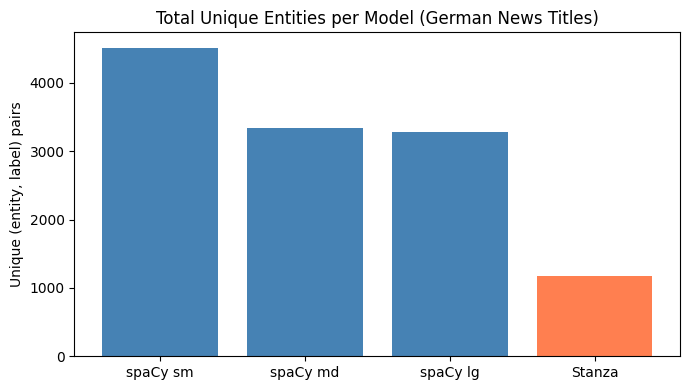

In [12]:
import matplotlib.pyplot as plt

# How many unique entities did each model find in total?
models = ["spaCy sm", "spaCy md", "spaCy lg", "Stanza"]
sizes  = [len(spacy_sm_ents), len(spacy_md_ents), len(spacy_lg_ents), len(stanza_ents)]

plt.figure(figsize=(7, 4))
plt.bar(models, sizes, color=["steelblue", "steelblue", "steelblue", "coral"])
plt.title("Total Unique Entities per Model (German News Titles)")
plt.ylabel("Unique (entity, label) pairs")
plt.tight_layout()
plt.savefig("overlap.png", dpi=150)
plt.show()

### Confusion heatmap

In [13]:
# Build dicts: entity text -> label for each model
spacy_map = dict(zip(df_spacy_lg["entity"], df_spacy_lg["label"]))
stanza_map = dict(zip(df_stanza["entity"], df_stanza["label"]))

# Find entities both models found but labelled differently
shared_texts = set(spacy_map.keys()) & set(stanza_map.keys())

disagreements = [
    {
        "entity": text,
        "spacy_label": spacy_map[text],
        "stanza_label": stanza_map[text],
    }
    for text in shared_texts
    if spacy_map[text] != stanza_map[text]
]

df_disagreements = pd.DataFrame(disagreements)
print(f"Disagreements: {len(df_disagreements)}")
df_disagreements.head(20)

Disagreements: 152


,entity,spacy_label,stanza_label
0,Museum für Alle,LOC,ORG
1,Bosch Areal,LOC,ORG
2,IBM Watson,MISC,ORG
3,Demeter,PER,ORG
4,Apollo,MISC,LOC
5,Internationalen Raumstation,MISC,LOC
6,German,MISC,LOC
7,Corona,LOC,ORG
8,One Belt,LOC,MISC
9,Berlinale,MISC,ORG


In [14]:
df_disagreements.to_csv("spacy_stanza_disagreements.csv", index=False)

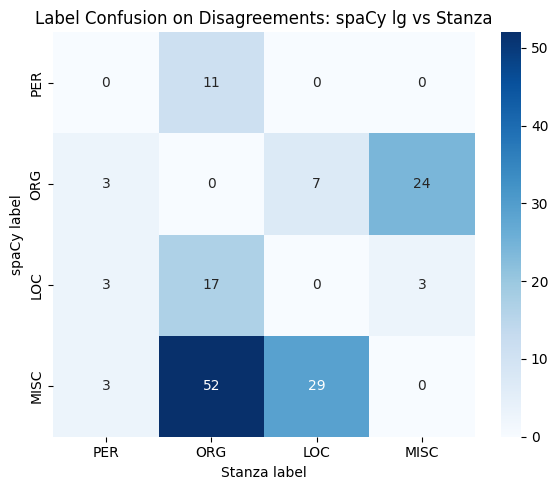

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# A confusion matrix shows where labels disagree
# Rows = what spaCy said, Columns = what Stanza said
# e.g. if cell [MISC, ORG] = 12, it means spaCy called 12 entities MISC
# that Stanza called ORG — this is the interesting linguistic disagreement

labels_order = ["PER", "ORG", "LOC", "MISC"]
cm = confusion_matrix(
    df_disagreements["spacy_label"],   # what spaCy said
    df_disagreements["stanza_label"],  # what Stanza said
    labels=labels_order
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels_order,
            yticklabels=labels_order,
            cmap="Blues")
plt.xlabel("Stanza label")
plt.ylabel("spaCy label")
plt.title("Label Confusion on Disagreements: spaCy lg vs Stanza")
plt.tight_layout()
plt.savefig("confusion.png", dpi=150)
plt.show()